# Regresión Lineal Simple

 - Variable a predecir (target): Avaluo
 - Variable predictorra : Cilindraje

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Estilo gráfico profesional
sns.set(style="whitegrid", palette="dark", font_scale=1.2)



In [ ]:
df = pd.read_csv("vehiculos_2025_SRI.csv")

df.head(2)


In [15]:
#Eliminar columnas duplicadas por registros repetidos
df = df.drop_duplicates()

# Convertir valores numéricos (avaluo, cilindrada)
df["AVALUO"] = df["AVALUO"].astype(str).str.replace(",", ".").astype(float)
df["CILINDRAJE"] = pd.to_numeric(df["CILINDRAJE"], errors="coerce")

# Convertir fechas
df["FECHA PROCESO (DD/MM/AAAA)"] = pd.to_datetime(df["FECHA PROCESO (DD/MM/AAAA)"], format="%d/%m/%Y")
df["FECHA COMPRA (DD/MM/AAAA)"] = pd.to_datetime(df["FECHA COMPRA (DD/MM/AAAA)"], format="%d/%m/%Y")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 436602 entries, 0 to 482753
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   CATEGORÍA                   436602 non-null  int64         
 1   CÓDIGO DE VEHÍCULO          436602 non-null  int64         
 2   TIPO TRANSACCIÓN            436602 non-null  object        
 3   MARCA                       436602 non-null  object        
 4   MODELO                      436602 non-null  object        
 5   PAIS                        436602 non-null  object        
 6   AÑO MODELO                  436602 non-null  int64         
 7   CLASE                       436602 non-null  object        
 8   SUB CLASE                   436602 non-null  object        
 9   TIPO                        436602 non-null  object        
 10  AVALUO                      436602 non-null  float64       
 11  FECHA PROCESO (DD/MM/AAAA)  436602 non-null 

In [42]:
df['AVALUO'].describe()

count    4.366020e+05
mean     1.171014e+04
std      2.130951e+04
min      7.000000e+01
25%      1.313240e+03
50%      1.999000e+03
75%      1.969000e+04
max      1.682685e+06
Name: AVALUO, dtype: float64

In [43]:
df['CILINDRAJE'].describe()

count    436602.000000
mean        837.272832
std        1406.509728
min           0.000000
25%         149.000000
50%         200.000000
75%        1485.000000
max       18037.000000
Name: CILINDRAJE, dtype: float64

## Miramos la dispersión de los puntos.

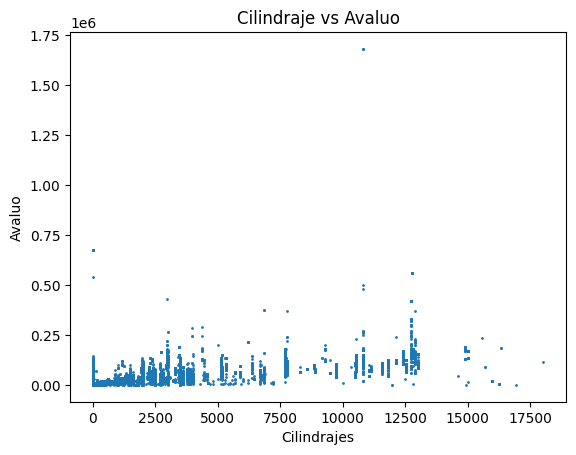

In [26]:
# Hacemos un diagrama de dispersión.
plt.scatter( df['CILINDRAJE'],df['AVALUO'], s = 1 )
#plt.plot( df['CILINDRAJE'],df['AVALUO'],'o', markersize=1)
plt.title("Cilindraje vs Avaluo")
plt.xlabel("Cilindrajes")
plt.ylabel("Avaluo")
plt.show()

## Dividimos el dataset para Entrenamiento y Prueba

In [32]:
X_cilindraje = df[['CILINDRAJE']]
y_avaluo = df['AVALUO']

In [33]:
# Dividimos el dataset: 80% para entrenamiento - 20% para prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_cilindraje, y_avaluo, test_size = 0.2, random_state = 42)
print("X train = ", X_train.shape)
print("X test = ", X_test.shape)
print("y train = ", y_train.shape)
print("y test = ", y_test.shape)

X train =  (349281, 1)
X test =  (87321, 1)
y train =  (349281,)
y test =  (87321,)


## Creo el Modelo Lineal

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [35]:
# Entrnamo el modelo
# X_train = X_train.values.reshape(-1, 1)
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Métricas de Evaluación

### Coeficiente de determinación

In [36]:
from sklearn.metrics import r2_score
#X_text = X_test.values.reshape(-1,1)
y_test_predict = lin_model.predict(X_test)    # Con los datos de X_test probamos el modelo
r2 = r2_score(y_test, y_test_predict)         # Comparamos los datos reales con los predichos
print("El desempeño del modelo en el conjunto de test es:")
print("--------------------------------------")
print("La puntuación de R2 es: {}".format(r2))

El desempeño del modelo en el conjunto de test es:
--------------------------------------
La puntuación de R2 es: 0.5740764720785747


### Miramos al pendiente y el intecepto cpn el eje y

In [38]:
print('Coeficiente: m =  ', lin_model.coef_[0])
print('Término independoente: b = ', lin_model.intercept_)

Coeficiente: m =   11.67251143184264
Término independoente: b =  1931.397204164603


 # y = 11.67251143184264x + 1931.397204164603

### Predicciones

In [39]:
# df['anios_experiencia'].values.reshape(-1,1) --> este formato debemos ponerlo para que nos responda el modelo
predicted_avaluo = lin_model.predict(df['CILINDRAJE'].values.reshape(-1,1))    
predicted_avaluo

C:\Users\mmunoz\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([150662.5378687 ,  76331.98507073,  60293.95436338, ...,
         4837.85255069,   4837.85255069,  36948.93149969], shape=(436602,))

## Dibujamos la Línea que mejor se ajusta a los datos.

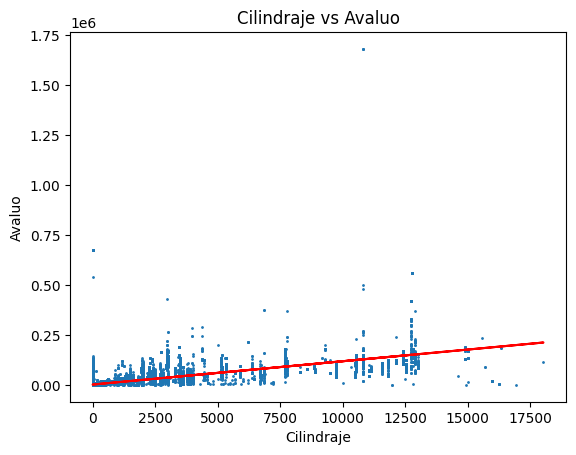

In [45]:
plt.scatter(df['CILINDRAJE'], df['AVALUO'], s = 1)
plt.plot(df['CILINDRAJE'], predicted_avaluo, color = 'red')
plt.title('Cilindraje vs Avaluo')
plt.xlabel('Cilindraje')
plt.ylabel('Avaluo')
plt.show()

## Vamos a ver los valores reales y los predichos

In [46]:
df1 = pd.DataFrame({'Real':df['AVALUO'], 'Predicción': predicted_avaluo})
df1

,Real,Predicción
0,240000.00,150662.537869
1,103192.00,76331.985071
2,32092.75,60293.954363
3,47250.00,46286.940645
4,969.98,3390.461133
...,...,...
482749,4729.82,25276.420068
482750,433.20,4837.852551
482751,433.20,4837.852551
482752,433.20,4837.852551


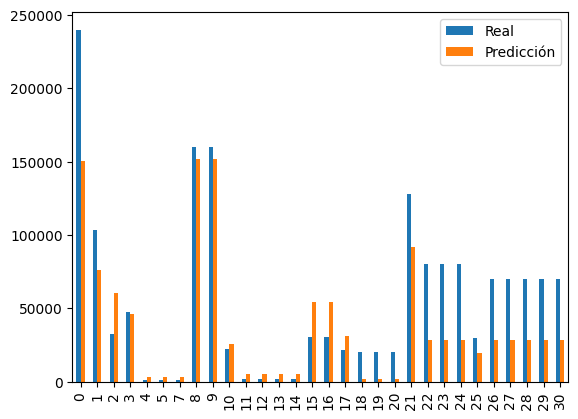

In [47]:
df1.head(30).plot(kind = 'bar')
plt.show()

## Residuos vs Valores Predichos

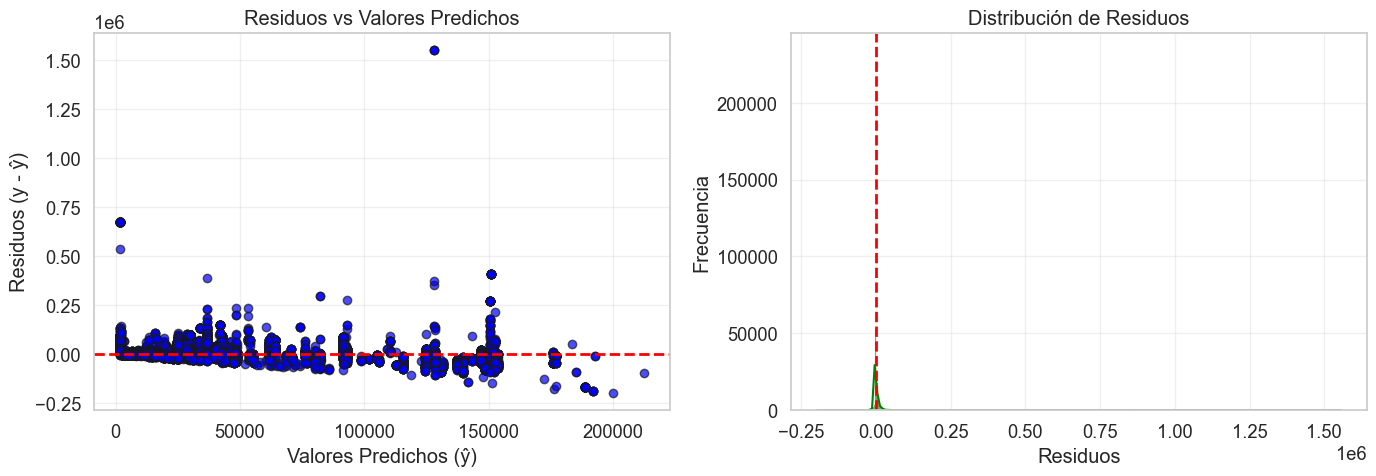

In [52]:
residuos = df['AVALUO'] - predicted_avaluo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Residuos vs Valores Predichos
axes[0].scatter(predicted_avaluo, residuos, color='blue', alpha=0.7, edgecolors='k')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valores Predichos (ŷ)')
axes[0].set_ylabel('Residuos (y - ŷ)')
axes[0].set_title('Residuos vs Valores Predichos')
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Distribución de Residuos (Histograma + KDE)
sns.histplot(residuos, kde=True, ax=axes[1], color='green', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuos')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# 5. Métricas del modelo
print(f"R²: {r2_score(df['AVALUO'], predicted_avaluo):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(df['AVALUO'], predicted_avaluo)):.4f}")
print(f"Media de residuos: {np.mean(residuos):.4f}")

R²: 0.5915
RMSE: 13620.2320
Media de residuos: 5.6646
